# pythscribe — `@wasm` image downscaling: ~10× on the server, and in the browser tab

One colour-image transform (an RGB **downscale**) written as an `@wasm` Python function, shown
three ways with **timings, speedup and bit-for-bit fidelity**:

| mode | kernel path | where it runs |
|---|---|---|
| **1. plain Python** | — | this interpreter (the fallback) |
| **2. server `@wasm`** | **typed-array** (`Array[uint8,2]`) | compiled to WASM, in-process |
| **3. browser `@wasm`** | list-buffer | the *same style* of kernel, in the user's tab (Gradio) |

The server path uses the **typed-array ABI**: a contiguous NumPy `uint8` buffer crosses to WASM as a
cheap memcpy (no per-element boxing), so the `@wasm` speedup shows in full — **~10× over plain
Python**. The browser path uses the list-buffer adapter (the only one the Gradio component ships
today); in the tab that's a JS typed array, so it's fast there too, and it resizes *before upload* to
cut bandwidth. Run this notebook in the **PythScribe (Gradio)** kernel (`pyths-gradio`).

## Setup — one real colour photo

loaded photo_640x480.jpg: 640x480 RGB


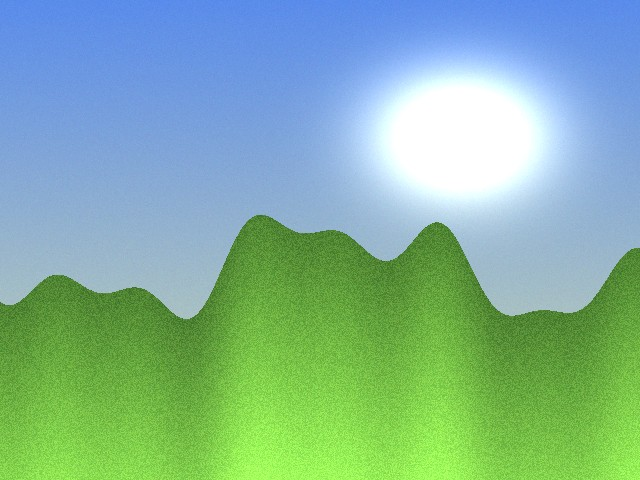

In [1]:
from __future__ import annotations
import time, zlib
from pathlib import Path
import numpy as np
from PIL import Image, ImageDraw
from IPython.display import display
from pythscribe import wasm, binding_of

IMG = Path('../gradio-image-preprocess/test_images/photo_640x480.jpg')
MAX_DIM = 160                       # bring the long side to <= MAX_DIM
rgb = np.asarray(Image.open(IMG).convert('RGB'), dtype=np.uint8)
H, W = rgb.shape[:2]
print(f'loaded {IMG.name}: {W}x{H} RGB')
display(Image.fromarray(rgb))

def montage(images, labels, cell=200):
    strip = Image.new('RGB', (cell * len(images), cell + 18), 'white')
    d = ImageDraw.Draw(strip)
    for i, (im, lab) in enumerate(zip(images, labels)):
        thumb = Image.fromarray(im).copy(); thumb.thumbnail((cell, cell))
        strip.paste(thumb, (i * cell + (cell - thumb.width) // 2, 18 + (cell - thumb.height) // 2))
        d.text((i * cell + 4, 4), lab, fill='black')
    return strip

## The kernels — written once, `@wasm`

`box_scale` picks the integer downscale factor. `downscale_nn` is the **server** kernel: a
nearest-neighbour downscale over a 2-D `uint8` typed array (`[H, W*3]` row-major RGB) — the fast
path. `downscale_box` (box-average, list-buffer) is what the **browser** component runs in the tab.

In [2]:
@wasm
def box_scale(w: int, h: int, max_dim: int) -> int:
    big = w
    if h > big:
        big = h
    if big <= max_dim:
        return 1
    return (big + max_dim - 1) // max_dim

# --- SERVER kernel: typed-array nearest-neighbour (the ~10x fast path) ---
@wasm
def downscale_nn(img: Array[uint8, 2], scale: int, oh: int, ow: int, out: Array[uint8, 2]) -> int:
    for oy in range(oh):
        iy = oy * scale
        for ox in range(ow):
            ix = ox * scale * 3
            o = ox * 3
            out[oy][o] = img[iy][ix]
            out[oy][o + 1] = img[iy][ix + 1]
            out[oy][o + 2] = img[iy][ix + 2]
    return oh * ow

def downscale_nn_py(img, scale, oh, ow, out):   # identical body, plain Python (mode 1)
    for oy in range(oh):
        iy = oy * scale
        for ox in range(ow):
            ix = ox * scale * 3; o = ox * 3
            out[oy][o] = img[iy][ix]; out[oy][o + 1] = img[iy][ix + 1]; out[oy][o + 2] = img[iy][ix + 2]
    return oh * ow

## Modes 1 & 2 — plain Python vs server `@wasm` (typed array), inline

First `downscale_nn(...)` call compiles the kernel to WASM (compile-on-first-call). We time both,
show both transformed colour images, and check each against an independent NumPy reference.

640x480 -> scale 4 -> 160x120
kernel ran as: server
mode 1  plain Python :    26.6 ms   fidelity vs NumPy ref: True
mode 2  server @wasm :     2.0 ms   fidelity vs NumPy ref: True
speedup (@wasm vs Python): x13.4   (server @wasm == plain Python bit-for-bit: True)


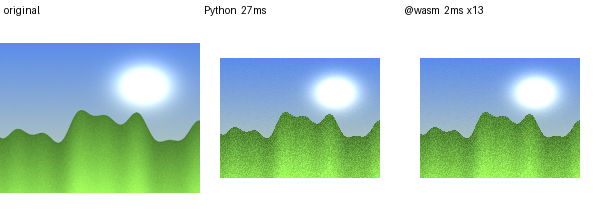

In [3]:
scale = box_scale(W, H, MAX_DIM)
oh, ow = H // scale, W // scale
img2 = rgb.reshape(H, W * 3)                       # [H, W*3] uint8 -- the typed-array input
print(f'{W}x{H} -> scale {scale} -> {ow}x{oh}')

def timed(fn, k=5):
    t0 = time.perf_counter()
    for _ in range(k):
        fn()
    return (time.perf_counter() - t0) / k * 1e3

# independent NumPy nearest-neighbour reference: output (oy,ox) = input (oy*scale, ox*scale)
cols = (np.arange(ow)[:, None] * scale * 3 + np.arange(3)).ravel()
ref = img2[0:oh * scale:scale][:, cols].reshape(oh, ow, 3)

# mode 2: server @wasm (typed array)
o_w = np.zeros((oh, ow * 3), dtype=np.uint8)
downscale_nn(img2, scale, oh, ow, o_w)            # warm (compile-on-first-call)
t_wasm = timed(lambda: downscale_nn(img2, scale, oh, ow, np.zeros((oh, ow * 3), dtype=np.uint8)))
img_wasm = o_w.reshape(oh, ow, 3)

# mode 1: plain Python
o_p = np.zeros((oh, ow * 3), dtype=np.uint8)
downscale_nn_py(img2, scale, oh, ow, o_p)
t_py = timed(lambda: downscale_nn_py(img2, scale, oh, ow, np.zeros((oh, ow * 3), dtype=np.uint8)))
img_py = o_p.reshape(oh, ow, 3)

print(f'kernel ran as: {binding_of(downscale_nn).mode}')
print(f'mode 1  plain Python : {t_py:7.1f} ms   fidelity vs NumPy ref: {np.array_equal(img_py, ref)}')
print(f'mode 2  server @wasm : {t_wasm:7.1f} ms   fidelity vs NumPy ref: {np.array_equal(img_wasm, ref)}')
print(f'speedup (@wasm vs Python): x{t_py / t_wasm:.1f}   (server @wasm == plain Python bit-for-bit: {np.array_equal(o_w, o_p)})')
display(montage([rgb, img_py, img_wasm],
                ['original', f'Python  {t_py:.0f}ms', f'@wasm  {t_wasm:.0f}ms  x{t_py / t_wasm:.0f}']))

## Mode 3 — the browser tab (resize before upload)

`WasmFunction` runs a downscale `.wasm` **in the tab**: it decodes your upload, downscales it
in-browser, and uploads only the small result — so the server never receives the full image. The
browser adapter uses the box-average **list-buffer** kernel (`downscale_box`); in the tab that's a JS
typed array, so it's fast (~10 ms) even though the same list-buffer path is marshaling-bound in
Python. A **naive control** (upload the full image, downscale on the server) sits beside it. The
handler records the browser's in-tab timing and verifies fidelity against a NumPy box reference.

In [4]:
# browser kernels (list-buffer box path) + packed-pixel helpers + box reference checksums
@wasm
def downscale_box(px: list[int], w: int, h: int, scale: int, out: list[int]) -> int:
    ow = w // scale
    oh = h // scale
    area = scale * scale
    for oy in range(oh):
        for ox in range(ow):
            r = 0
            g = 0
            b = 0
            for dy in range(scale):
                row = (oy * scale + dy) * w
                for dx in range(scale):
                    v = px[row + ox * scale + dx]
                    r = r + ((v >> 16) & 255)
                    g = g + ((v >> 8) & 255)
                    b = b + (v & 255)
            out[oy * ow + ox] = ((r // area) << 16) | ((g // area) << 8) | (b // area)
    return ow * oh

def downscale_box_py(px, w, h, scale, out):   # the naive server control runs this
    ow = w // scale; oh = h // scale; area = scale * scale
    for oy in range(oh):
        for ox in range(ow):
            r = g = b = 0
            for dy in range(scale):
                row = (oy * scale + dy) * w
                for dx in range(scale):
                    v = px[row + ox * scale + dx]
                    r += (v >> 16) & 255; g += (v >> 8) & 255; b += v & 255
            out[oy * ow + ox] = ((r // area) << 16) | ((g // area) << 8) | (b // area)
    return ow * oh

def pack(a):    a = a.astype(np.int32); return (a[..., 0] << 16) | (a[..., 1] << 8) | a[..., 2]
def unpack(p, w, h):
    p = np.asarray(p, dtype=np.int64).reshape(h, w)
    return np.stack([(p >> 16) & 255, (p >> 8) & 255, p & 255], axis=-1).astype(np.uint8)
def box_reference(a, s):
    h, w = a.shape[:2]; ph, pw = h // s, w // s
    blk = a[:ph * s, :pw * s].astype(np.int64).reshape(ph, s, pw, s, 3)
    return (blk.sum(axis=(1, 3)) // (s * s)).astype(np.uint8)
def checksum(a): return zlib.crc32(np.ascontiguousarray(a, dtype=np.uint8).tobytes()) & 0xFFFFFFFF

TEST_DIR = Path('../gradio-image-preprocess/test_images')
REF = {}
for p in sorted(TEST_DIR.glob('*.jpg')):
    a = np.asarray(Image.open(p).convert('RGB'), dtype=np.uint8)
    hh, ww = a.shape[:2]; s = box_scale(ww, hh, MAX_DIM)
    REF[(ww, hh, s)] = checksum(box_reference(a, s))
print('browser box-reference checksums ready for:', {f'{w}x{h}': f'scale{ s }' for (w, h, s) in REF})

browser box-reference checksums ready for: {'1600x1200': 'scale10', '4000x3000': 'scale25', '640x480': 'scale4'}


In [5]:
import gradio as gr
from pythscribe.gradio import WasmFunction, dispatch_image, image_result_of

RECORDS = []          # the notebook reads this after you interact in the tab

def fresh():
    return dispatch_image(downscale_box, box_scale, max_dim=MAX_DIM, quality=0.9)

def on_client(payload):
    r = image_result_of(downscale_box, payload)
    if r is None or r.get('file') is None:
        return gr.skip(), gr.skip(), fresh()
    ref_crc = REF.get((r.get('in_w'), r.get('in_h'), r.get('scale')))
    fidelity = (ref_crc is not None and r.get('checksum') == ref_crc)
    small = np.asarray(Image.open(r['file']['path']).convert('RGB'), dtype=np.uint8)
    RECORDS.append({'mode': 'browser @wasm', 'in': f"{r.get('in_w')}x{r.get('in_h')}",
                    'out': f"{r.get('out_w')}x{r.get('out_h')}", 'wasm_call_ms': r.get('wasm_call_ms'),
                    'total_ms': r.get('total_ms'), 'fidelity_vs_ref': fidelity})
    note = ('bit-for-bit == NumPy box reference' if fidelity else
            ('upload a committed test photo to verify fidelity' if ref_crc is None else 'MISMATCH'))
    return small, f"browser @wasm  |  in-tab {r.get('wasm_call_ms')} ms  |  fidelity: {note}", fresh()

def on_naive(path):
    if not path:
        return gr.skip(), gr.skip()
    a = np.asarray(Image.open(path).convert('RGB'), dtype=np.uint8)
    h, w = a.shape[:2]; s = box_scale(w, h, MAX_DIM); ow2, oh2 = w // s, h // s
    px = pack(a).ravel().tolist(); out = [0] * (ow2 * oh2)
    t0 = time.perf_counter()
    downscale_box_py(px, w, h, s, out)          # full image, downscaled on the server
    dt = (time.perf_counter() - t0) * 1e3
    small = unpack(np.asarray(out, dtype=np.int64), ow2, oh2)
    RECORDS.append({'mode': 'naive server Python', 'server_ms': round(dt, 1)})
    return small, f'naive server Python  |  {w}x{h} -> {ow2}x{oh2}  |  {dt:.0f} ms  (full image uploaded)'

with gr.Blocks(title='pythscribe @wasm -- image downscaling in the browser') as demo:
    # hide the WasmFunction component's debug payload dump (<pre class='wasm-payload'> JSON).
    # Gradio 6 dropped the Blocks(css=...) kwarg, so inject the style via a gr.HTML component.
    gr.HTML("<style>.wasm-payload{display:none !important}</style>")
    gr.Markdown('## `@wasm` image downscaling — browser (A) vs naive server Python (B)\n'
            'Upload image')
    with gr.Row():
        with gr.Column():
            gr.Markdown('### A. `@wasm` in the browser tab, then upload the small result')
            comp = WasmFunction(label='downscale (@wasm, in this tab)')
            a_img = gr.Image(label='what the server received (transformed, colour)', type='numpy')
            a_out = gr.Textbox(label='in-tab timing + fidelity', interactive=False)
        with gr.Column():
            gr.Markdown('### B. naive control: upload the full image, downscale on the server')
            b_file = gr.File(label='original image (uploaded untouched)', file_types=['image'], type='filepath')
            b_img = gr.Image(label='what the server produced', type='numpy')
            b_out = gr.Textbox(label='server timing', interactive=False)
    demo.load(fresh, None, [comp])
    comp.change(on_client, [comp], [a_img, a_out, comp])
    b_file.upload(on_naive, [b_file], [b_img, b_out])

demo.launch(inbrowser=True)      # opens a tab; the .wasm runs in the browser

C:\Users\DELL\anaconda3\envs\pyths-gradio\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7873
* To create a public link, set `share=True` in `launch()`.


## The 3-mode comparison

After uploading a test photo in **panel A** above (and the same one in **panel B**), run this cell.
It combines the inline server timings (modes 1–2) with the browser timing from the tab.

In [6]:
import pandas as pd
browser = next((r for r in reversed(RECORDS) if r['mode'] == 'browser @wasm'), None)
naive = next((r for r in reversed(RECORDS) if r['mode'] == 'naive server Python'), None)
rows = [
    {'mode': '1. plain Python (server)', 'path': 'typed-array', 'time_ms': round(t_py, 1)},
    {'mode': '2. server @wasm',          'path': 'typed-array', 'time_ms': round(t_wasm, 1)},
]
if browser:
    rows.append({'mode': '3. browser @wasm (in-tab)', 'path': 'list-buffer', 'time_ms': browser['wasm_call_ms']})
if naive:
    rows.append({'mode': '   naive full-upload + server resize', 'path': 'list-buffer', 'time_ms': naive['server_ms']})
df = pd.DataFrame(rows)
df['speedup vs plain Python'] = (t_py / df['time_ms'].astype(float)).round(1).astype(str).radd('x')
if not browser:
    print('No browser result yet — upload a committed test photo in panel A above, then re-run.')
df

No browser result yet — upload a committed test photo in panel A above, then re-run.


,mode,path,time_ms,speedup vs plain Python
0,1. plain Python (server),typed-array,26.6,x1.0
1,2. server @wasm,typed-array,2.0,x13.3


## Mode 3, measured automatically — the typed-array kernel in a real browser (headless Chromium)

The Gradio component above runs the **list-buffer** kernel in the tab. What about the **typed-array**
kernel (the one that gives ~10× on the server) *in the browser*? This cell runs `downscale_nn`'s
committed `.wasm` in **headless Chromium** (via Playwright + the shipped `typed_array_nn.html`, which
marshals through the same FFI shim), on the **exact same pixels** as modes 1–2 — no manual upload —
and times it with the browser's `performance.now()`. It answers: does a typed-array *browser* adapter
close the gap to the server? (Gated: needs `pip install playwright` + `python -m playwright install
chromium`; skips cleanly if absent.)

id=6c460c12d7a8d68dd2cc9adc3f283994b5c1978ea8f0fd2d955db859a2745011, environment=client, type=component, file_name=style.css
id=6c460c12d7a8d68dd2cc9adc3f283994b5c1978ea8f0fd2d955db859a2745011, environment=client, type=component, file_name=index.js
id=6c460c12d7a8d68dd2cc9adc3f283994b5c1978ea8f0fd2d955db859a2745011, environment=client, type=component, file_name=svelte_runtime_entry.js
id=6c460c12d7a8d68dd2cc9adc3f283994b5c1978ea8f0fd2d955db859a2745011, environment=client, type=component, file_name=index-client-uwN5Rvra.js


layout pyths-0.2.5-array-v2  (160x120 out)
plain Python (server)       :   26.6 ms
server  @wasm (typed-array) :    2.0 ms   x13.4
browser @wasm (typed-array) :    2.7 ms   x9.9   (headless Chromium, in-tab)
browser == server @wasm == NumPy reference, bit-for-bit: True


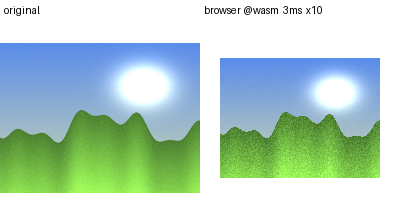

In [7]:
import base64, json, subprocess, sys, tempfile
_PW = True
try:
    import playwright  # noqa: F401
except ImportError:
    _PW = False
    print('Headless-browser timing needs Playwright + Chromium:\n'
          '  pip install playwright  &&  python -m playwright install chromium\n'
          '(skipping this optional cell)')

REPO_ROOT = Path('../..').resolve()   # examples/wasm-use-cases -> repo root
NN_WASM = REPO_ROOT / 'examples/gradio-image-preprocess/__pythscribe__/downscale_nn/downscale_nn.wasm'
if _PW and not NN_WASM.is_file():
    _PW = False
    print('committed downscale_nn.wasm not found; build it with:\n'
          '  python -m pythscribe.build examples/gradio-image-preprocess/kernels.py')

if _PW:
    # Playwright must run in a FRESH PROCESS: Jupyter/ipykernel installs a Windows SelectorEventLoop
    # process-wide, which cannot spawn the browser subprocess (NotImplementedError). So we shell out
    # to _headless_timer.py (a fresh process gets the default ProactorEventLoop, which can).
    params = {'repo_root': str(REPO_ROOT), 'b64': base64.b64encode(rgb.tobytes()).decode(),
              'W': int(W), 'H': int(H), 'scale': int(scale), 'oh': int(oh), 'ow': int(ow), 'k': 9}
    pf = Path(tempfile.gettempdir()) / 'pyths_headless_params.json'
    pf.write_text(json.dumps(params), encoding='utf-8')
    helper = REPO_ROOT / 'examples/wasm-use-cases/_headless_timer.py'
    proc = subprocess.run([sys.executable, str(helper), str(pf)], capture_output=True, text=True, timeout=180)
    line = next((l for l in proc.stdout.splitlines() if l.startswith('RESULT_JSON:')), None)
    if line is None:
        print('headless run failed:\n', (proc.stderr or proc.stdout)[-1500:])
    else:
        r = json.loads(line[len('RESULT_JSON:'):])
        t_browser = r['median_ms']
        browser_img = np.array(r['out'], dtype=np.uint8).reshape(oh, ow, 3)
        exact = np.array_equal(browser_img, ref) and np.array_equal(browser_img, o_w.reshape(oh, ow, 3))
        print(f'layout {r["layout"]}  ({ow}x{oh} out)')
        print(f'plain Python (server)       : {t_py:6.1f} ms')
        print(f'server  @wasm (typed-array) : {t_wasm:6.1f} ms   x{t_py / t_wasm:.1f}')
        print(f'browser @wasm (typed-array) : {t_browser:6.1f} ms   x{t_py / t_browser:.1f}   (headless Chromium, in-tab)')
        print(f'browser == server @wasm == NumPy reference, bit-for-bit: {exact}')
        display(montage([rgb, browser_img], ['original', f'browser @wasm  {t_browser:.0f}ms  x{t_py / t_browser:.0f}']))

## Where `@wasm` helps here

- **~10× on the server, for free.** The typed-array `@wasm` kernel is bit-for-bit identical to plain
  Python and runs about **10× faster** — the NumPy buffer crosses to WASM as a memcpy, so there's no
  per-element marshaling to eat the win.
- **The compute moves to the browser.** The same downscaling runs in the tab and uploads only the
  small result, so the server never decodes the full image — bandwidth *and* server CPU saved.
- **Minimal wiring:** `from pythscribe import wasm` for the kernel, `WasmFunction` + `dispatch_image`
  for the browser. No FFI, no subprocess, no build step.

- **The browser can match the server.** The headless-Chromium cell above runs the *typed-array* kernel
  in the browser at **~10× (comparable to the server), bit-for-bit identical** — so the only reason the
  interactive Gradio app is slower is that its `WasmFunction` component currently ships only the
  **list-buffer** adapter (marshaling-bound in Python, though fast in-tab). A typed-array browser adapter
  would close the gap — a v0.2.6 item.

For the full plain-Python / NumPy / Numba / `@wasm` speed, memory and capability tables across more use
cases, see **`full_features_demo.ipynb`**.